<div class="usecase-title">Urban Pedestrian Climate Impact Prediction</div>

<div class="usecase-authors"><b>Authored by: </b> Maverick Nguyen</div>

<div class="usecase-duration"><b>Duration:</b> 90 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, Data Cleaning, Data Validation, Data Visualisation, Time-Series Analysis, Feature Engineering, Optimisation Methods, Deep Learning</div>
</div>

<div class="usecase-section-header">Scenario</div>

As a local living near Melbourne CBD, Maverick relies on active travel, like walking, and public transport, like trams, to get around to different places he wants to go. One morning in January, Maverick prepared to travel to his workplace, expecting to get to work before 9:00 AM, but there was a sudden heatwave, causing the tram that he usually catches to be unable to follow its designated schedule and creating a delay in his schedule. Although there was a replacement bus for this emergency, only a limited number of people could board this vehicle, which further delayed his schedule. Because of this sudden extreme weather, travel conditions become less reliable and difficult to predict.

Maverick wants to have access to a system that could predict how climate conditions over time can affect urban pedestrian movement. So that he could better plan his trip, allowing him to leave earlier in anticipation of sudden extreme weather change during a particular timeframe, or choose a different mode of transport, like an Uber. This allows more support in making informed decisions when travelling during extreme weather events.

<div class="usecase-section-header">What this use case will teach you</div>

At the end of this use case, you will:
- Learn how to source and combine multiple public datasets.  
- Understand how to clean and align time-series data at an hourly level for modelling. 
- Explore how climate variables, such as temperature, humidity, pressure, and wind, relate to pedestrian counts.
- Apply feature engineering techniques to create meaningful predictors from weather and mobility time-series data. 
- Build a deep learning forecasting model to predict pedestrian demand. 
- Perform model optimisation like hyperparameter tuning to improve forecasting performance. 
- Evaluate model performance and interpret results for climate adaptation planning.

<div class="usecase-section-header">Introduction</div>

Urban systems are often affected by changing climate conditions, but these effects are not always easy to capture with simple forecasting methods. One clear example is pedestrian movement, where changing weather conditions can affect how many people move through the city over time.

This use case focuses on predicting pedestrian activity in the City of Melbourne using hourly climate observations, which keeps the project closely aligned with the goal of modelling how climate factors influence an urban system.

In this use case, pedestrian counts are aggregated into hourly city-level totals and merged with hourly microclimate observations for Melbourne. A deep learning model can then be trained to predict pedestrian demand based on time, recent demand history, and recent climate conditions.

The datasets used in this project are the "Pedestrian Counting System (counts per hour)", the "Pedestrian Counting System - Sensor Locations" dataset for supporting location metadata, and the "Microclimate Sensor Readings" dataset from the City of Melbourne website.

## 1. Importing The Libraries

This section is to show what libraries were used for this use case, with each imported library supporting a specific part of the pipeline. These libraries are necessary for doing data handling, time-series analysis, visualisation, feature engineering, optimisation, and deep learning.

In [11]:
# Libraries for this project.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler

## 2. Importing The Datasets

This section is necessary for importing multiple public datasets from the City of Melbourne. By using a shared BASE_URL and a dictionary of dataset identifiers, this allows for removing and adding datasets more easily. The get_csv_url() function is especially useful because it standardises the dataset access method and allows the same logic to be reused across all three datasets. The ROW_LIMIT parameter was added to allow experimentation on smaller samples before scaling to the full dataset. Lastly, the datasets are accessed through the Melbourne Open Data API v2.1, and no visible API key is exposed in the code.

In [13]:
# Store the API base path accessed via API v2.1.
BASE_URL = (
    "https://data.melbourne.vic.gov.au"
    "/api/explore/v2.1/catalog/datasets"
)

# Store the dataset identifiers.
DATASETS = {
    "sensor_locations":
        "pedestrian-counting-system-sensor-locations",
    "pedestrian_counts":
        "pedestrian-counting-system-monthly-counts-per-hour",
    "microclimate":
        "microclimate-sensors-data",
}

# Set the number of rows to retrieve for experiments.
# Change to "None" when full datasets are needed.
# Change to an integer for experimental purposes.
ROW_LIMIT = None 

def get_csv_url(dataset_id, row_limit=None):
    # Build the base CSV export URL.
    url = (
        f"{BASE_URL}/{dataset_id}/exports/csv"
        f"?delimiter=,&with_bom=true"
    )

    # Add a row limit if one is provided.
    if row_limit is not None:
        url += f"&limit={row_limit}"

    return url

### 2.1 Pedestrian Counting System - Sensor Locations

This dataset was included to provide contextual information about the physical pedestrian counting network, even though it wasn't used in the later steps for modelling. The sensor metadata helps explain where the mobility data originates from and what the coverage of the system looks like.

* `location_id`: unique identifier for each pedestrian counting location.
* `sensor_description`: human-readable description of the site, like street names.
* `sensor_name`: short internal sensor code.
* `installation_date`: date the sensor was installed.
* `note`: extra comments or metadata about the sensor.
* `location_type`: type of location.
* `status`: operational status of the sensor.
* `direction_1` and `direction_2`: the two movement directions captured by the counter.
* `latitude` and `longitude`: geographic coordinates of the sensor.
* `location`: combined coordinate string.

In [15]:
# Load the sensor locations dataset.
sensor_locations_df = pd.read_csv(
    get_csv_url(
        DATASETS["sensor_locations"],
        row_limit=ROW_LIMIT
    ),
    encoding="utf-8-sig"
)

# Preview the dataframe.
print(sensor_locations_df.head())

   location_id             sensor_description sensor_name installation_date  \
0            1     Bourke Street Mall (North)    Bou292_T        2009-03-24   
1            4               Town Hall (West)    Swa123_T        2009-03-23   
2           10                 Victoria Point    BouHbr_T        2009-04-23   
3           11                Waterfront City    WatCit_T        2009-01-20   
4           24  Spencer St-Collins St (North)    Col620_T        2013-09-02   

  note location_type status direction_1 direction_2   latitude   longitude  \
0  NaN       Outdoor      A        East        West -37.813494  144.965153   
1  NaN       Outdoor      A       North       South -37.814880  144.966088   
2  NaN       Outdoor      A        East        West -37.818765  144.947105   
3  NaN       Outdoor      A        East        West -37.815650  144.939707   
4  NaN       Outdoor      A        East        West -37.818880  144.954492   

                     location  
0  -37.81349441, 144.965

### 2.2 Pedestrian Counting System (counts per hour)

This is the target dataset for the use case because the final prediction task is to forecast pedestrian demand. The pedestrian dataset contains the observed mobility outcome that the model aims to learn.

* `id`: record identifier.
* `location_id`: identifier linking the observation to a specific sensor location.
* `sensing_date`: date of observation.
* `hourday`: hour of day from 0 to 23.
* `direction_1` and `direction_2`: directional pedestrian counts.
* `pedestriancount`: total pedestrian count for that record.
* `sensor_name`: short sensor code.
* `location`: coordinate string for the sensor. 

In [17]:
# Load the pedestrian counts dataset.
pedestrian_counts_df = pd.read_csv(
    get_csv_url(
        DATASETS["pedestrian_counts"],
        row_limit=ROW_LIMIT
    ),
    encoding="utf-8-sig"
)

# Preview the dataframe.
print(pedestrian_counts_df.head())

              id  location_id sensing_date  hourday  direction_1  direction_2  \
0   211020240830           21   2024-08-30       10          158           97   
1  1241520251111          124   2025-11-11       15            2            3   
2  1341520240612          134   2024-06-12       15          363          322   
3  1352320250616          135   2025-06-16       23           14           23   
4  1331020250614          133   2025-06-14       10          406          416   

   pedestriancount  sensor_name                    location  
0              255  Bourke155_T  -37.81267313, 144.96788288  
1                5  BirBridge_T  -37.81757416, 144.97329934  
2              685    Spen201_T  -37.81694221, 144.95303935  
3               37    Spen161_T   -37.8172861, 144.95319102  
4              822    Spen229_T  -37.81531435, 144.95227769  


### 2.3 Microclimate sensors data

This dataset provides the microclimate data that the use case requires to understand how climate conditions affect urban pedestrian movement, more specifically, the input features. It basically provides the explanatory environmental variables to connect weather conditions to mobility demand. 

* `device_id`: identifier for each microclimate device.
* `received_at`: timestamp when the reading was recorded.
* `sensorlocation`: descriptive location of the microclimate sensor.
* `latlong`: coordinate string.
* `minimumwinddirection`, `averagewinddirection`, `maximumwinddirection`: wind direction measurements.
* `minimumwindspeed`, `averagewindspeed`, `gustwindspeed`: wind speed measurements.
* `airtemperature`: air temperature reading.
* `relativehumidity`: humidity level.
* `atmosphericpressure`: atmospheric pressure.
* `pm25` and `pm10`: particulate matter measurements.
* `noise`: noise level. 

In [19]:
# Load the microclimate dataset.
microclimate_df = pd.read_csv(
    get_csv_url(
        DATASETS["microclimate"],
        row_limit=ROW_LIMIT
    ),
    encoding="utf-8-sig"
)

# Preview the dataframe.
print(microclimate_df.head())

            device_id                received_at  \
0  ICTMicroclimate-09  2025-11-16T03:47:32+00:00   
1  ICTMicroclimate-03  2025-11-16T04:14:45+00:00   
2  ICTMicroclimate-05  2025-08-23T18:58:22+00:00   
3  ICTMicroclimate-01  2025-08-23T18:57:53+00:00   
4  ICTMicroclimate-11  2025-08-23T15:31:41+00:00   

                                      sensorlocation  \
0  SkyFarm (Jeff's Shed). Rooftop - Melbourne Con...   
1                                        CH1 rooftop   
2                 Enterprize Park - Pole ID: COM1667   
3                    Birrarung Marr Park - Pole 1131   
4                                   1 Treasury Place   

                    latlong  minimumwinddirection  averagewinddirection  \
0  -37.8223306, 144.9521696                   0.0                   0.0   
1    -37.8140348, 144.96728                 187.0                 240.0   
2  -37.8204083, 144.9591192                   0.0                   0.0   
3  -37.8185931, 144.9716404                   NaN 

## 3. Initial Inspection Of The Datasets

This section is necessary to understand the size, structure, completeness and formatting of public datasets since they often differ. Before trying to clean and merge the datasets, understanding what each of the datasets contains and how they can be combined is important.

### 3.1 Checking Number Of Rows/Columns

Checking the shape is important because it shows the scale and complexity of each dataset. This helps determine memory demands, cleaning strategy, and whether the data volume is sufficient for later modelling. 

The volume for each task varies, but from the inspection of the shapes, there appears to be sufficient volume for the task of predicting the pedestrian count.

In [22]:
# Preview of the number of columns and rows.
print(sensor_locations_df.shape)
print(pedestrian_counts_df.shape)
print(microclimate_df.shape)

(145, 12)
(1467767, 9)
(591803, 16)


### 3.2 Checking The Features

This step is to verify what information is actually available in each dataset, and whether there are meaningful fields for later joining, cleaning, and modelling. Knowing the columns early prevents accidentally removing important variables or keeping irrelevant variables.

From the output, the column names confirm that location_id is shared between the sensor metadata and pedestrian counts datasets. Also, the pedestrian and microclimate datasets both contain time information, which is essential because the final merge is ultimately done at the hourly level. The microclimate dataset clearly offers a diverse range of explanatory variables, which is useful for modelling. And, some columns that are likely less useful for the final model need to be removed, such as descriptive notes, raw coordinate strings, and duplicate directional fields.

In [24]:
# Check the column names for each dataframe.
print("Sensor locations columns:")
print(sensor_locations_df.columns)

print("\nPedestrian counts columns:")
print(pedestrian_counts_df.columns)

print("\nMicroclimate columns:")
print(microclimate_df.columns)

Sensor locations columns:
Index(['location_id', 'sensor_description', 'sensor_name', 'installation_date',
       'note', 'location_type', 'status', 'direction_1', 'direction_2',
       'latitude', 'longitude', 'location'],
      dtype='object')

Pedestrian counts columns:
Index(['id', 'location_id', 'sensing_date', 'hourday', 'direction_1',
       'direction_2', 'pedestriancount', 'sensor_name', 'location'],
      dtype='object')

Microclimate columns:
Index(['device_id', 'received_at', 'sensorlocation', 'latlong',
       'minimumwinddirection', 'averagewinddirection', 'maximumwinddirection',
       'minimumwindspeed', 'averagewindspeed', 'gustwindspeed',
       'airtemperature', 'relativehumidity', 'atmosphericpressure', 'pm25',
       'pm10', 'noise'],
      dtype='object')


### 3.3 Checking The Datatypes

Datatype checking is essential because many later operations depend on correct types to proceed. Steps like date parsing, numeric aggregation, interpolation, rolling windows, and model preparation can all fail or behave incorrectly if types are wrong.

From the outputs, the pedestrian sensing_date, sensor installation_date, and microclimate received_at fields are all initially stored as objects, so they are not yet ready for time-series operations, which will need to be dealt with. And the numeric climate variables are already in float64, and pedestrian counts are in int64, which is appropriate for aggregation and modelling, so no need to change that.

In [26]:
# Check the data types for each dataframe.
print("Sensor locations data types:")
print(sensor_locations_df.dtypes)

print("\nPedestrian counts data types:")
print(pedestrian_counts_df.dtypes)

print("\nMicroclimate data types:")
print(microclimate_df.dtypes)

Sensor locations data types:
location_id             int64
sensor_description     object
sensor_name            object
installation_date      object
note                   object
location_type          object
status                 object
direction_1            object
direction_2            object
latitude              float64
longitude             float64
location               object
dtype: object

Pedestrian counts data types:
id                  int64
location_id         int64
sensing_date       object
hourday             int64
direction_1         int64
direction_2         int64
pedestriancount     int64
sensor_name        object
location           object
dtype: object

Microclimate data types:
device_id                object
received_at              object
sensorlocation           object
latlong                  object
minimumwinddirection    float64
averagewinddirection    float64
maximumwinddirection    float64
minimumwindspeed        float64
averagewindspeed        float64
gust

### 3.4 Checking The Dataset Information

Using .info() gives a more complete structural summary of the datasets, which shows non-null counts, memory usage, and dtype balance. But this step will focus more on the memory that will be used up in the RAM, to decide what sample size would be ideal for experimentation before scaling to the full dataset size, or opt for a platform like Google Colab to handle more heavy usage.

From the outputs, the pedestrian dataset takes up the most memory, followed by the microclimate dataset, with the sensor locations dataset being extremely low. Which is acceptable to run locally for modelling.

In [28]:
# Check the overall structure of each dataframe.
print("Sensor locations info:")
print(sensor_locations_df.info())

print("\nPedestrian counts info:")
print(pedestrian_counts_df.info())

print("\nMicroclimate info:")
print(microclimate_df.info())

Sensor locations info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   location_id         145 non-null    int64  
 1   sensor_description  145 non-null    object 
 2   sensor_name         145 non-null    object 
 3   installation_date   145 non-null    object 
 4   note                34 non-null     object 
 5   location_type       145 non-null    object 
 6   status              145 non-null    object 
 7   direction_1         113 non-null    object 
 8   direction_2         113 non-null    object 
 9   latitude            145 non-null    float64
 10  longitude           145 non-null    float64
 11  location            145 non-null    object 
dtypes: float64(2), int64(1), object(9)
memory usage: 13.7+ KB
None

Pedestrian counts info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1467767 entries, 0 to 1467766
Data columns 

### 3.5 Checking For Missing Values

Checking for missing values is important, since it affects the cleaning strategy, feature selection, and merge quality. This is especially important because missing sensor readings can break hourly continuity for the modelling later.

From the outputs, the pedestrian counts dataset has no missing values at all. The microclimate dataset has many missing values in all the variables besides device_id and received_at. And the sensor locations dataset has some missing values, mainly in note, direction_1, and direction_2, which are not necessary for city-level forecasting.

In [30]:
# Count the missing values in each dataframe.
print("Missing values in sensor locations:")
print(sensor_locations_df.isna().sum())

print("\nMissing values in pedestrian counts:")
print(pedestrian_counts_df.isna().sum())

print("\nMissing values in microclimate:")
print(microclimate_df.isna().sum())

Missing values in sensor locations:
location_id             0
sensor_description      0
sensor_name             0
installation_date       0
note                  111
location_type           0
status                  0
direction_1            32
direction_2            32
latitude                0
longitude               0
location                0
dtype: int64

Missing values in pedestrian counts:
id                 0
location_id        0
sensing_date       0
hourday            0
direction_1        0
direction_2        0
pedestriancount    0
sensor_name        0
location           0
dtype: int64

Missing values in microclimate:
device_id                   0
received_at                 0
sensorlocation           6143
latlong                 11483
minimumwinddirection    61942
averagewinddirection      649
maximumwinddirection    62104
minimumwindspeed        62104
averagewindspeed          651
gustwindspeed           62104
airtemperature            651
relativehumidity          651
atmosp

### 3.6 Checking Summary Statistics

Checking the summary statistics is an easy way to provide some early insights into the datasets, like central tendency and spread.

From the sensor coordinates with the mean latitude and longitude, the Melbourne CBD can be inferred to be the main area of focus for the datasets. The pedestrian counts are strongly right-skewed, with the median count being a fair bit lower than the mean, and the maximum being really high, which suggests that some hours and sites are much busier than others. The average microclimate temperature is about 16.3°C, and the average relative humidity is about 66.3%, which looks plausible for Melbourne across a long time range.

In [32]:
# Check the summary statistics for numeric columns.
print("Sensor locations summary:")
print(sensor_locations_df.describe())

print("\nPedestrian counts summary:")
print(pedestrian_counts_df.describe())

print("\nMicroclimate summary:")
print(microclimate_df.describe())

Sensor locations summary:
       location_id    latitude   longitude
count   145.000000  145.000000  145.000000
mean     93.075862  -37.812392  144.960427
std      55.229079    0.006999    0.009594
min       1.000000  -37.825910  144.928606
25%      47.000000  -37.816888  144.956447
50%      89.000000  -37.813625  144.961860
75%     142.000000  -37.807767  144.965626
max     188.000000  -37.789353  144.986388

Pedestrian counts summary:
                 id   location_id       hourday   direction_1   direction_2  \
count  1.467767e+06  1.467767e+06  1.467767e+06  1.467767e+06  1.467767e+06   
mean   4.797800e+11  7.265999e+01  1.182776e+01  1.881479e+02  1.931191e+02   
std    5.115114e+11  5.016046e+01  6.778309e+00  2.924281e+02  3.030145e+02   
min    1.020240e+09  1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    6.912025e+10  3.100000e+01  6.000000e+00  1.800000e+01  1.900000e+01   
50%    2.511203e+11  6.200000e+01  1.200000e+01  7.800000e+01  7.700000e+01   
75%   

### 3.7 Checking The Date Format

Checking the date format is important because a time-based merge depends on all datasets sharing a compatible datetime structure, and public datasets often use different date formats and timezone conventions.

The pedestrian dataset stores dates and hours separately. Whereas the microclimate dataset stores the full timestamps with date and time with UTC offsets. And the sensor installation date is a simple date string and is mainly historical metadata rather than a modelling field. This makes it clear that datetime standardisation is a required step before any merge can occur.

In [34]:
# Check a few date values before conversion.
print("Pedestrian sensing_date sample:")
print(pedestrian_counts_df["sensing_date"].head())

print("\nMicroclimate received_at sample:")
print(microclimate_df["received_at"].head())

print("\nSensor installation_date sample:")
print(sensor_locations_df["installation_date"].head())

Pedestrian sensing_date sample:
0    2024-08-30
1    2025-11-11
2    2024-06-12
3    2025-06-16
4    2025-06-14
Name: sensing_date, dtype: object

Microclimate received_at sample:
0    2025-11-16T03:47:32+00:00
1    2025-11-16T04:14:45+00:00
2    2025-08-23T18:58:22+00:00
3    2025-08-23T18:57:53+00:00
4    2025-08-23T15:31:41+00:00
Name: received_at, dtype: object

Sensor installation_date sample:
0    2009-03-24
1    2009-03-23
2    2009-04-23
3    2009-01-20
4    2013-09-02
Name: installation_date, dtype: object


### 3.8 Checking The ID Columns

This was an additional step for checking the unique identifiers to see if the datasets have any chance of being joined directly by ID or whether another strategy, like a datetime merge, is best.

From the outputs, the sensor locations dataset contains 137 unique location_id values, while the pedestrian counts dataset contains 100 unique location_id values. Whereas the microclimate dataset contains 12 unique device_id values, which is a completely different identifier system. This means the microclimate data cannot be joined to pedestrian counts by location ID, so a time-based merge is the best integration method available.

In [36]:
# Check important identifier columns.
print("Unique location_id values in sensor locations:")
print(sensor_locations_df["location_id"].nunique())

print("\nUnique location_id values in pedestrian counts:")
print(pedestrian_counts_df["location_id"].nunique())

print("\nUnique device_id values in microclimate:")
print(microclimate_df["device_id"].nunique())

Unique location_id values in sensor locations:
137

Unique location_id values in pedestrian counts:
100

Unique device_id values in microclimate:
12


## 4. Data Cleaning

This is the section for data cleaning, since raw data are rarely ready to be used as it is, so cleaning processes are necessary to address duplicates, missing values, inconsistencies, syntax errors, irrelevant data and structural errors. And since this data pipeline uses the API for dataset access, this means that the datasets are being updated in real-time, so ensuring any errors get addressed in the pipeline ensures the data remains accurate, secure and accessible at every stage of its lifecycle. And that the prediction will also be accurate.

### 4.1 Removing Irrelevant Columns

Selecting relevant variables and removing the irrelevant ones are necessary because not every feature is useful for the prediction modelling. This step also has the added benefit of reducing memory usage in later steps.

In this step, the sensor dataset is reduced to six useful metadata columns, even though it wasn't used for modelling purposes. The pedestrian dataset is reduced to the four fields needed to construct hourly counts. The microclimate dataset is reduced to key climate, air quality, and noise variables. The descriptive or duplicate variables were omitted.

In [39]:
# Keep only useful columns.
sensor_locations_clean = sensor_locations_df[
    [
        "location_id",
        "sensor_description",
        "installation_date",
        "status",
        "latitude",
        "longitude",
    ]
].copy()

pedestrian_clean = pedestrian_counts_df[
    [
        "location_id",
        "sensing_date",
        "hourday",
        "pedestriancount",
    ]
].copy()

microclimate_clean = microclimate_df[
    [
        "device_id",
        "received_at",
        "airtemperature",
        "relativehumidity",
        "atmosphericpressure",
        "averagewindspeed",
        "gustwindspeed",
        "averagewinddirection",
        "pm25",
        "pm10",
        "noise",
    ]
].copy()

# Check the result.
print(sensor_locations_clean.head())
print(pedestrian_clean.head())
print(microclimate_clean.head())

   location_id             sensor_description installation_date status  \
0            1     Bourke Street Mall (North)        2009-03-24      A   
1            4               Town Hall (West)        2009-03-23      A   
2           10                 Victoria Point        2009-04-23      A   
3           11                Waterfront City        2009-01-20      A   
4           24  Spencer St-Collins St (North)        2013-09-02      A   

    latitude   longitude  
0 -37.813494  144.965153  
1 -37.814880  144.966088  
2 -37.818765  144.947105  
3 -37.815650  144.939707  
4 -37.818880  144.954492  
   location_id sensing_date  hourday  pedestriancount
0           21   2024-08-30       10              255
1          124   2025-11-11       15                5
2          134   2024-06-12       15              685
3          135   2025-06-16       23               37
4          133   2025-06-14       10              822
            device_id                received_at  airtemperature  \
0

### 4.2 Removing Missing Value

This step involves dealing with missing values by removing the rows they're in. This is because missing values in explanatory variables can cause problems when doing aggregation, interpolation, and modelling later.

After doing the column selection in the previous step, the sensor and pedestrian tables are now fully complete without missing values. Whereas the microclimate table still has many missing values, especially in gustwindspeed, pm25, pm10, and noise. By using dropna(), the microclimate dataset lost a number of data points with missing values, but still retains a sizable portion of data points. The decision for completeness in the data points was preferred to simplify the merging and feature engineering steps later, and because there were enough data points for it not to matter much.

In [41]:
# Check missing values after column selection.
print("Missing values in sensor_locations_clean:")
print(sensor_locations_clean.isna().sum())

print("\nMissing values in pedestrian_clean:")
print(pedestrian_clean.isna().sum())

print("\nMissing values in microclimate_clean:")
print(microclimate_clean.isna().sum())

Missing values in sensor_locations_clean:
location_id           0
sensor_description    0
installation_date     0
status                0
latitude              0
longitude             0
dtype: int64

Missing values in pedestrian_clean:
location_id        0
sensing_date       0
hourday            0
pedestriancount    0
dtype: int64

Missing values in microclimate_clean:
device_id                   0
received_at                 0
airtemperature            651
relativehumidity          651
atmosphericpressure       651
averagewindspeed          651
gustwindspeed           62104
averagewinddirection      649
pm25                    31387
pm10                    31387
noise                   31387
dtype: int64


In [42]:
# Remove rows with any missing values from each dataset.
sensor_locations_clean = sensor_locations_clean.dropna().copy()
pedestrian_clean = pedestrian_clean.dropna().copy()
microclimate_clean = microclimate_clean.dropna().copy()

# Check missing values after removal.
print("\nMissing values in sensor_locations_clean:")
print(sensor_locations_clean.isna().sum())
print(sensor_locations_clean.shape)

print("\nMissing values in pedestrian_clean:")
print(pedestrian_clean.isna().sum())
print(pedestrian_clean.shape)

print("\nMissing values in microclimate_clean:")
print(microclimate_clean.isna().sum())
print(microclimate_clean.shape)


Missing values in sensor_locations_clean:
location_id           0
sensor_description    0
installation_date     0
status                0
latitude              0
longitude             0
dtype: int64
(145, 6)

Missing values in pedestrian_clean:
location_id        0
sensing_date       0
hourday            0
pedestriancount    0
dtype: int64
(1467767, 4)

Missing values in microclimate_clean:
device_id               0
received_at             0
airtemperature          0
relativehumidity        0
atmosphericpressure     0
averagewindspeed        0
gustwindspeed           0
averagewinddirection    0
pm25                    0
pm10                    0
noise                   0
dtype: int64
(498963, 11)


### 4.3 Datetime Formatting

Ensuring the datetime formatting matches between the different datasets is important because the modelling is hourly, and the datasets need to be able to merge based on a common point. Skipping this step would mean that the datasets cannot be merged into one table.

The pedestrian dataset is converted from separate sensing_date and hourday fields into a single datetime_hour, such as 2024-12-06 20:00:00. Whereas the microclimate timestamps are converted from UTC into Australia/Melbourne, timezone information is removed, and the values are floored to the nearest hour. By doing this, both datasets now have a datetime variable with the same time formatting. It's also important to note that the time range of the microclimate dataset is narrower than the pedestrian time range, meaning that the overlap period is limited to the microclimate dataset.

In [44]:
# Convert sensor installation date.
sensor_locations_clean["installation_date"] = pd.to_datetime(
    sensor_locations_clean["installation_date"]
)

# Create an hourly datetime for pedestrian data.
pedestrian_clean["sensing_date"] = pd.to_datetime(
    pedestrian_clean["sensing_date"]
)

pedestrian_clean["datetime_hour"] = (
    pedestrian_clean["sensing_date"] +
    pd.to_timedelta(pedestrian_clean["hourday"], unit="h")
)

# Check the result.
print(pedestrian_clean.head())

   location_id sensing_date  hourday  pedestriancount       datetime_hour
0           21   2024-08-30       10              255 2024-08-30 10:00:00
1          124   2025-11-11       15                5 2025-11-11 15:00:00
2          134   2024-06-12       15              685 2024-06-12 15:00:00
3          135   2025-06-16       23               37 2025-06-16 23:00:00
4          133   2025-06-14       10              822 2025-06-14 10:00:00


In [45]:
# Convert the raw timestamp to datetime with UTC.
microclimate_clean["received_at"] = pd.to_datetime(
    microclimate_clean["received_at"],
    utc=True
)

# Convert UTC to Melbourne local time.
microclimate_clean["received_at"] = (
    microclimate_clean["received_at"]
    .dt.tz_convert("Australia/Melbourne")
)

# Remove the timezone after conversion.
microclimate_clean["received_at"] = (
    microclimate_clean["received_at"]
    .dt.tz_localize(None)
)

# Round down to the nearest hour.
microclimate_clean["datetime_hour"] = (
    microclimate_clean["received_at"]
    .dt.floor("h")
)

# Check the result.
print(microclimate_clean.head())

            device_id         received_at  airtemperature  relativehumidity  \
0  ICTMicroclimate-09 2025-11-16 14:47:32            18.5              50.0   
1  ICTMicroclimate-03 2025-11-16 15:14:45            18.5              51.5   
2  ICTMicroclimate-05 2025-08-24 04:58:22             8.3              88.4   
4  ICTMicroclimate-11 2025-08-24 01:31:41             9.2              75.7   
5  ICTMicroclimate-06 2025-08-24 01:34:17             7.5              81.4   

   atmosphericpressure  averagewindspeed  gustwindspeed  averagewinddirection  \
0                999.5               1.1            5.0                   0.0   
1                994.8               0.8            0.5                 240.0   
2               1024.4               0.0            0.5                   0.0   
4               1021.1               0.0            0.8                   0.0   
5               1025.3               0.1            3.4                   9.0   

   pm25  pm10  noise       datetime_ho

In [46]:
# Confirming the same datetime format.
print("Pedestrian time range:")
print(pedestrian_clean["datetime_hour"].min())
print(pedestrian_clean["datetime_hour"].max())

print("\nMicroclimate time range:")
print(microclimate_clean["datetime_hour"].min())
print(microclimate_clean["datetime_hour"].max())

Pedestrian time range:
2024-03-29 00:00:00
2026-03-28 03:00:00

Microclimate time range:
2024-05-29 13:00:00
2026-02-20 10:00:00


### 4.4 Aggregating Values For Hourly Format

This step involves aggregation because the use case models city-level pedestrian demand rather than individual sensor-level behaviour. This also ensures that both the pedestrian and the microclimate data share the same hourly rows without duplicates for later merging.

The aggregation involves the pedestrian counts being summed across sensors to produce hourly city totals, and the microclimate readings are averaged across devices for each hour. Doing this changes the target variable from pedestrians at one site to overall city pedestrian demand at one hour, along with the climate values at that hour. This also further reduces the row counts due to aggregating to hourly, and the microclimate data is still narrower than the pedestrian dataset.

In [48]:
# Aggregate pedestrian counts to hourly city totals.
pedestrian_hourly = (
    pedestrian_clean
    .groupby("datetime_hour", as_index=False)
    .agg(
        {
            "pedestriancount": "sum",
        }
    )
)

# Check the result.
print(pedestrian_hourly.head())
print(pedestrian_hourly.shape)

        datetime_hour  pedestriancount
0 2024-03-29 00:00:00            14052
1 2024-03-29 01:00:00            10010
2 2024-03-29 02:00:00             4919
3 2024-03-29 03:00:00             3622
4 2024-03-29 04:00:00             2175
(17352, 2)


In [49]:
# Aggregate microclimate readings to hourly city averages.
microclimate_hourly = (
    microclimate_clean
    .groupby("datetime_hour", as_index=False)
    .agg(
        {
            "airtemperature": "mean",
            "relativehumidity": "mean",
            "atmosphericpressure": "mean",
            "averagewindspeed": "mean",
            "gustwindspeed": "mean",
            "averagewinddirection": "mean",
            "pm25": "mean",
            "pm10": "mean",
            "noise": "mean",
        }
    )
)

# Check the result.
print(microclimate_hourly.head())
print(microclimate_hourly.shape)

        datetime_hour  airtemperature  relativehumidity  atmosphericpressure  \
0 2024-05-29 13:00:00       19.428571         43.614286          1018.600000   
1 2024-05-29 14:00:00       19.522222         43.770370          1018.281481   
2 2024-05-29 15:00:00       19.329630         43.429630          1018.203704   
3 2024-05-29 16:00:00       18.788000         45.048000          1017.400000   
4 2024-05-29 17:00:00       17.904762         48.666667          1017.142857   

   averagewindspeed  gustwindspeed  averagewinddirection       pm25  \
0          2.400000       7.485714            252.000000  11.857143   
1          2.362963       6.970370            240.148148  11.851852   
2          2.125926       6.170370            190.925926  11.740741   
3          1.672000       5.588000            238.040000  11.400000   
4          1.728571       5.061905            226.714286  12.095238   

        pm10      noise  
0  13.428571  78.171429  
1  13.629630  76.737037  
2  13.407407  

### 4.5 Merging The Datasets

This step will merge the datasets together, ensuring the target variable, pedestrian count, is connected to the explanatory climate variables. The datetime_hour variable on both the pedestrian dataset and the microclimate dataset was inner-joined to merge into one dataset, meaning only the overlapping rows with the same values were merged. 

A quick check of the merged dataset shows that the pedestrian counts and climate values aligned in the same hourly observations, which is what the use case is looking for. And there are no missing values, which indicates that previous data cleaning works as intended.

In [51]:
# Merge pedestrian and microclimate data on the hourly datetime.
model_df = pd.merge(
    pedestrian_hourly,
    microclimate_hourly,
    on="datetime_hour",
    how="inner"
)

# Sort the final modelling table.
model_df = model_df.sort_values(
    "datetime_hour"
).reset_index(drop=True)

# Check the result.
print(model_df.head())
print(model_df.shape)

        datetime_hour  pedestriancount  airtemperature  relativehumidity  \
0 2024-05-29 13:00:00            57628       19.428571         43.614286   
1 2024-05-29 14:00:00            46483       19.522222         43.770370   
2 2024-05-29 15:00:00            49846       19.329630         43.429630   
3 2024-05-29 16:00:00            58939       18.788000         45.048000   
4 2024-05-29 17:00:00            69055       17.904762         48.666667   

   atmosphericpressure  averagewindspeed  gustwindspeed  averagewinddirection  \
0          1018.600000          2.400000       7.485714            252.000000   
1          1018.281481          2.362963       6.970370            240.148148   
2          1018.203704          2.125926       6.170370            190.925926   
3          1017.400000          1.672000       5.588000            238.040000   
4          1017.142857          1.728571       5.061905            226.714286   

        pm25       pm10      noise  
0  11.857143  13.42

In [52]:
# Check merged dataset.
print(model_df.info())
print("\nMissing values:")
print(model_df.isna().sum())
print("\nSummary statistics:")
print(model_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15020 entries, 0 to 15019
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime_hour         15020 non-null  datetime64[ns]
 1   pedestriancount       15020 non-null  int64         
 2   airtemperature        15020 non-null  float64       
 3   relativehumidity      15020 non-null  float64       
 4   atmosphericpressure   15020 non-null  float64       
 5   averagewindspeed      15020 non-null  float64       
 6   gustwindspeed         15020 non-null  float64       
 7   averagewinddirection  15020 non-null  float64       
 8   pm25                  15020 non-null  float64       
 9   pm10                  15020 non-null  float64       
 10  noise                 15020 non-null  float64       
dtypes: datetime64[ns](1), float64(9), int64(1)
memory usage: 1.3 MB
None

Missing values:
datetime_hour           0
pedestriancount     

## 5. Data Validation

Doing data validation is important because a merged dataset that was cleaned may still be unsuitable for the task of this use case, possibly due to timestamps being duplicated, out of order, or some rows in the chronological datetime are missing. The time-series model tends to assume a consistent temporal structure with no sudden breaks, so this step in the pipeline checks that everything is complete.

### 5.1 Validating Time Series Dataset

Checking for duplicates or missing timestamps, since they can affect the lag features, rolling features and any sequence-based deep learning models that this use case may use. This is to ensure that there is a strictly ordered sequence of evenly spaced time points.

From the outputs, there are no duplicates in the datetime_hour values, which means every timestamp is represented once. The dataset is double-checked to ensure that it is sorted in increasing time order. But there appears to be a number of missing hourly timestamps, which means the dataset is not complete yet. It does appear that random points were cut off, and that no large block of time was cut off.

In [55]:
# Count duplicate datetime values.
duplicate_count = model_df["datetime_hour"].duplicated().sum()

# Print the result.
print("Duplicate datetime_hour values:", duplicate_count)

Duplicate datetime_hour values: 0


In [56]:
# Create the full expected hourly range.
full_hours = pd.date_range(
    start=model_df["datetime_hour"].min(),
    end=model_df["datetime_hour"].max(),
    freq="h"
)

# Find missing hours.
missing_hours = full_hours.difference(model_df["datetime_hour"])

# Print the number of missing hours.
print("Number of missing hourly timestamps:", len(missing_hours))

# Preview a few missing hours.
print(missing_hours[:10])

Number of missing hourly timestamps: 146
DatetimeIndex(['2024-10-06 02:00:00', '2025-05-11 21:00:00',
               '2025-05-11 22:00:00', '2025-05-12 00:00:00',
               '2025-06-02 05:00:00', '2025-06-02 06:00:00',
               '2025-06-02 08:00:00', '2025-06-06 22:00:00',
               '2025-06-06 23:00:00', '2025-06-07 00:00:00'],
              dtype='datetime64[ns]', freq=None)


In [57]:
# Confirm the dataset is sorted by time.
print(model_df["datetime_hour"].is_monotonic_increasing)

True


### 5.2 Fixing Missing Timestamps

Ensuring the missing timestamps are filled in is necessary for a complete hourly sequence in the dataset, and missing them can create issues when performing feature engineering later.

This step involves reindexing to the full hourly range so that all the missing timestamps are included in the dataset, and then interpolation is performed to fill in the missing values from those created rows. Hence, the merged dataset now has slightly more rows with no missing hourly stamps, ensuring the timeline is continuous with no breaks. A little addition was included to ensure that the pedestrian counts remained as integers, rather than fractions, due to interpolation. 

In [59]:
# Set datetime as the index.
model_df = model_df.set_index("datetime_hour").sort_index()

# Create the full hourly timeline.
full_hours = pd.date_range(
    start=model_df.index.min(),
    end=model_df.index.max(),
    freq="h"
)

# Reindex to restore missing hours.
model_df = model_df.reindex(full_hours)

# Interpolate all numeric columns over time.
model_df = model_df.interpolate(method="time").ffill().bfill()

# Convert pedestrian count back to integers.
model_df["pedestriancount"] = (
    model_df["pedestriancount"]
    .round()
    .astype(int)
)

# Restore datetime_hour as a column.
model_df = model_df.reset_index().rename(
    columns={"index": "datetime_hour"}
)

# Check the result.
print("Missing hourly timestamps:",
      pd.date_range(
          model_df["datetime_hour"].min(),
          model_df["datetime_hour"].max(),
          freq="h"
      ).difference(model_df["datetime_hour"]).shape[0])

# Check for missing hourly timestamps again.
full_hours = pd.date_range(
    start=model_df["datetime_hour"].min(),
    end=model_df["datetime_hour"].max(),
    freq="h"
)

missing_hours = full_hours.difference(model_df["datetime_hour"])

# Check the dataset structure.
print("\nOverall:")
print(model_df.info())

# Check the final time range.
print("\nFinal time range:")
print(model_df["datetime_hour"].min())
print(model_df["datetime_hour"].max())

# Check the dataframe shape.
print("\nFinal shape:")
print(model_df.shape)

Missing hourly timestamps: 0

Overall:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15166 entries, 0 to 15165
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime_hour         15166 non-null  datetime64[ns]
 1   pedestriancount       15166 non-null  int32         
 2   airtemperature        15166 non-null  float64       
 3   relativehumidity      15166 non-null  float64       
 4   atmosphericpressure   15166 non-null  float64       
 5   averagewindspeed      15166 non-null  float64       
 6   gustwindspeed         15166 non-null  float64       
 7   averagewinddirection  15166 non-null  float64       
 8   pm25                  15166 non-null  float64       
 9   pm10                  15166 non-null  float64       
 10  noise                 15166 non-null  float64       
dtypes: datetime64[ns](1), float64(9), int32(1)
memory usage: 1.2 MB
None

Final time range:
2024-

## 6. Exploratory Data Analysis

The exploratory data analysis section was performed on the merged dataset to observe any interpretable patterns and get a rough understanding of how the dataset looks and feels before building a model. It's important to get a sense of how pedestrian demand changes over time and how it relates to the climate conditions.

### 6.1 Pedestrian Count Over Time (Hourly)

The hourly pedestrian counts were plotted directly to get a general idea of how it looks. And from the plot, there appear to be large fluctuations across the full time range with repeated highs and lows. Although it looks random, it does seem to show some sort of pattern, and it's not necessarily random noise, with recurring fluctuations, like the new year of each year seems to always be a high peak, indicating lots of pedestrians travelling in the city, and there also appear to be some sharp dips, which may possibly be public holidays. This does suggest that there may be other possible variables that might have influenced the pedestrian count, but it definitely confirms that pedestrian demand is influenced by recurring temporal and possibly environmental effects.

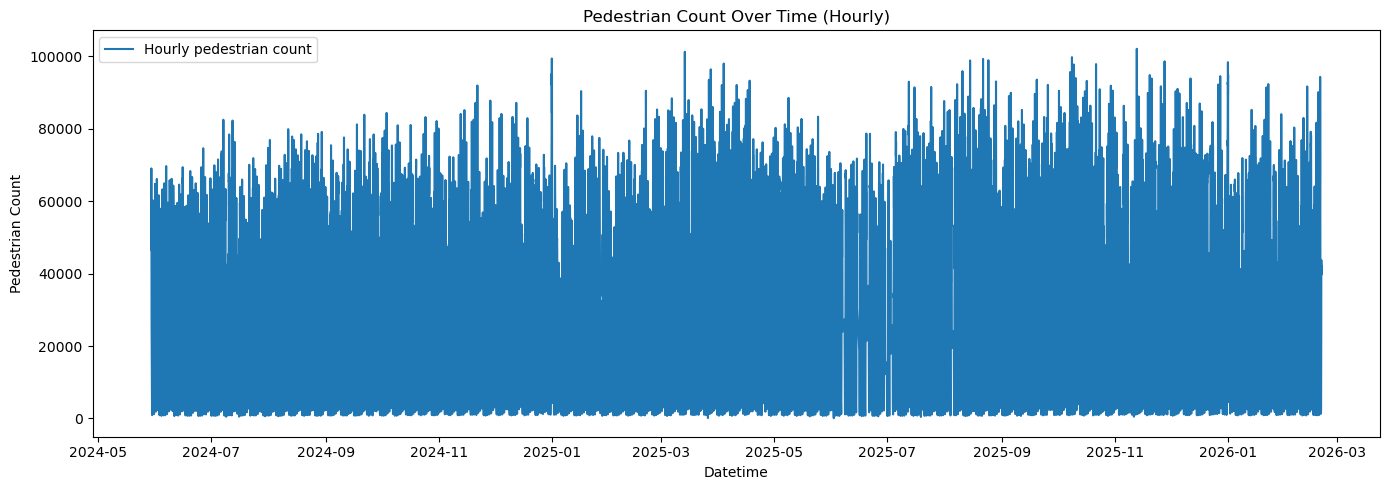

In [62]:
# Plot pedestrian counts over time.
plt.figure(figsize=(14, 5))
plt.plot(
    model_df["datetime_hour"],
    model_df["pedestriancount"],
    label="Hourly pedestrian count"
)

plt.title("Pedestrian Count Over Time (Hourly)")
plt.xlabel("Datetime")
plt.ylabel("Pedestrian Count")
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 Average Pedestrian Count By Day Of Week

The day-of-week summary was checked to see if there may also be other variables like work patterns, shopping activities, or weekend behaviours that might have influenced the pedestrian demand. From the plot, it does seem like the weekdays tend to be relatively high along with Saturdays, whereas Mondays and Sundays tend to have low pedestrian demands. Monday might be low despite being a normal workday for the average Australians might be due to the influence of public holidays, and Sunday being low is due to most people not working on Sunday, since businesses would usually pay a high penalty rate. This further suggests that the CBD pedestrian pattern is linked to weekday economic and commuter activity, not just climate variables.

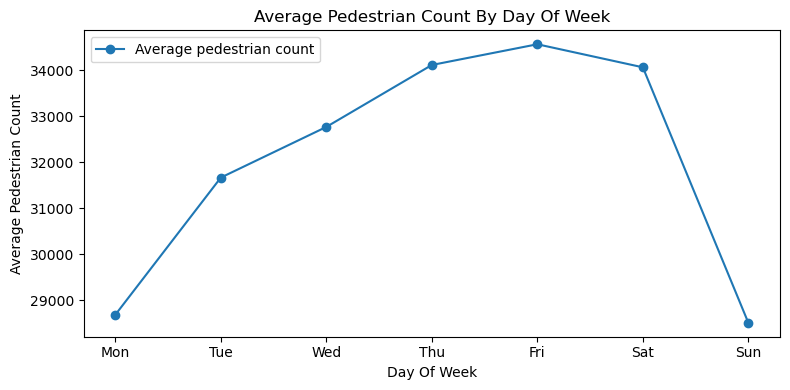

In [64]:
# Create a day-of-week column.
model_df["day_of_week"] = model_df[
    "datetime_hour"
].dt.dayofweek

# Group by day of week.
dow_pattern = model_df.groupby("day_of_week")[
    "pedestriancount"
].mean()

# Plot the day-of-week pattern.
plt.figure(figsize=(8, 4))
plt.plot(
    dow_pattern.index,
    dow_pattern.values,
    marker="o",
    label="Average pedestrian count"
)

plt.title("Average Pedestrian Count By Day Of Week")
plt.xlabel("Day Of Week")
plt.ylabel("Average Pedestrian Count")
plt.xticks(
    ticks=range(7),
    labels=[
        "Mon", "Tue", "Wed",
        "Thu", "Fri", "Sat", "Sun"
    ]
)
plt.legend()
plt.tight_layout()
plt.show()

### 6.3 Distributions Of Variables

Checking for distribution to see whether it's symmetric, skewed, or multi-modal. Since it may affect decisions for model selection later. From the plots, pedestrian counts are right-skewed, where there may be some period of time with very high pedestrian demand. Air temperature appears roughly unimodal with a slight right skew. Relative humidity is also unimodal with a slight left skew. Wind variables are unimodal and right-skewed, with the exception of wind direction being relatively normal-looking. Noise also appears normal-looking and unimodal as well. The pm25 and pm10 are both unimodal with right skewness. And atmospheric pressure is unimodal with left skewness.

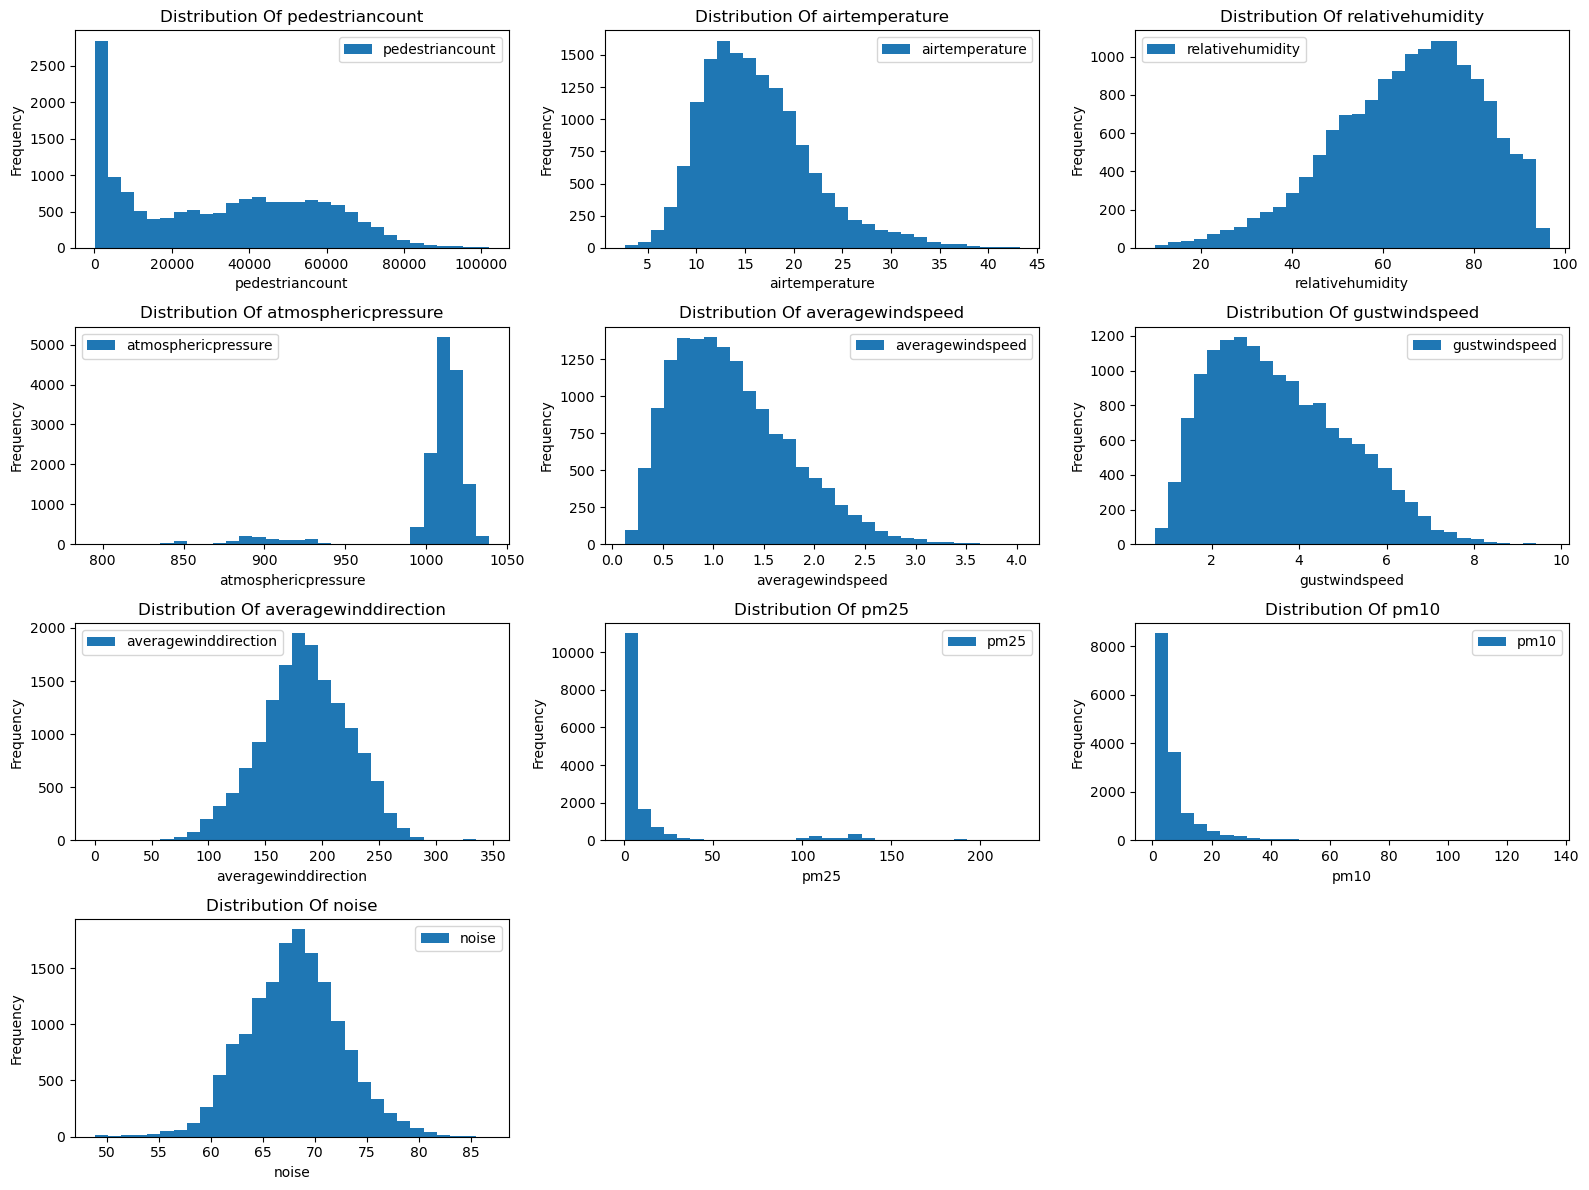

In [66]:
# Store numeric columns.
numeric_cols = model_df.select_dtypes(
    include=["int32", "int64", "float64"]
).columns.drop(
    ["day_of_week"],
    errors="ignore"
)

# Create subplot layout.
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 12)
)

axes = axes.flatten()

# Plot histogram for each numeric column.
for i, col in enumerate(numeric_cols):
    axes[i].hist(
        model_df[col],
        bins=30,
        label=col
    )
    axes[i].set_title(f"Distribution Of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

# Remove empty subplots.
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 6.4 Correlation Matrix

Checking the correlation matrix is a quick way to see which climate variables might have the strongest relationship with pedestrian demand, which does seem like they have some influence on the target variable from the results. Noise seems to have the strongest positive correlation with pedestrian demand, followed by gustwindspeed, averagewindspeed, airtemperature, averagewinddirection, and atmosphericpressure. The strongest negative correlation is relativehumidity, followed by pm10, and pm25. This suggests that climate variables do play a role in influencing the pedestrian demand, but there are other influences as well as discovered from previous plots. But the goal for this task is to understand how climate variables affect pedestrian demands.

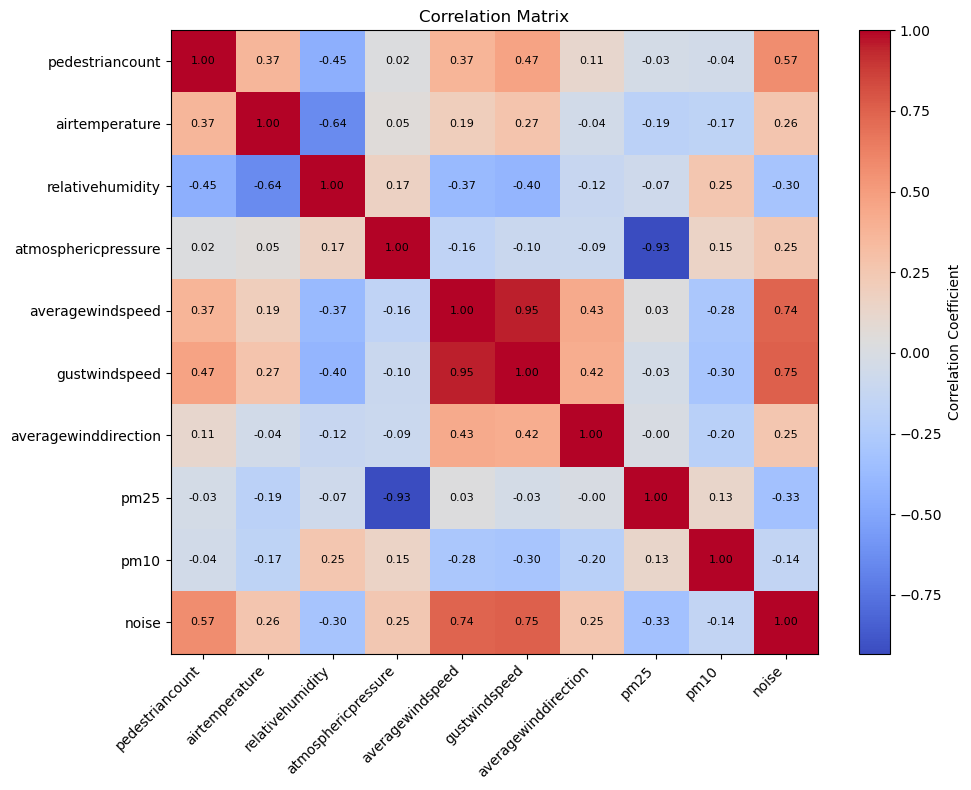

pedestriancount         1.000000
noise                   0.570051
gustwindspeed           0.470590
averagewindspeed        0.369469
airtemperature          0.365053
averagewinddirection    0.110525
atmosphericpressure     0.019197
pm25                   -0.033052
pm10                   -0.041896
relativehumidity       -0.448747
Name: pedestriancount, dtype: float64


In [68]:
# Calculate the correlation matrix.
corr_matrix = model_df[numeric_cols].corr()

# Plot the correlation matrix.
plt.figure(figsize=(10, 8))
im = plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    aspect="auto"
)

cbar = plt.colorbar(im)
cbar.set_label("Correlation Coefficient")

plt.xticks(
    ticks=np.arange(len(corr_matrix.columns)),
    labels=corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(corr_matrix.columns)),
    labels=corr_matrix.columns
)

plt.title("Correlation Matrix")

# Add values inside each cell.
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

# Print the correlation values with pedestrian count.
print(corr_matrix["pedestriancount"].sort_values(ascending=False))

## 7. Time Series Analysis

This section is necessary as exploratory data analysis alone is not enough to check a time series dataset. Hence, time series analysis is necessary to help uncover more trends, seasonality, repeated lag dependence, and stationarity.

### 7.1 Pedestrian Count Over Time (24-Hour Rolling Mean)

The previous plot with the pedestrian count over time was noisy, so smoothing over 24 hours may help reveal more patterns of pedestrian activity without the hour-to-hour volatility. From the plot, it became much more obvious that the highest peaks were during New Year's, where pedestrian visit the Melbourne CBD to see the fireworks, and confirms what has been previously discussed. There does seem to be a slightly increasing trend, which suggests that the influence of COVID-19 is still recovering.

In [71]:
# Create the hourly target series.
ts = model_df.set_index("datetime_hour")[
    "pedestriancount"
].sort_index()

# Check the first few rows.
print(ts.head())

datetime_hour
2024-05-29 13:00:00    57628
2024-05-29 14:00:00    46483
2024-05-29 15:00:00    49846
2024-05-29 16:00:00    58939
2024-05-29 17:00:00    69055
Name: pedestriancount, dtype: int32


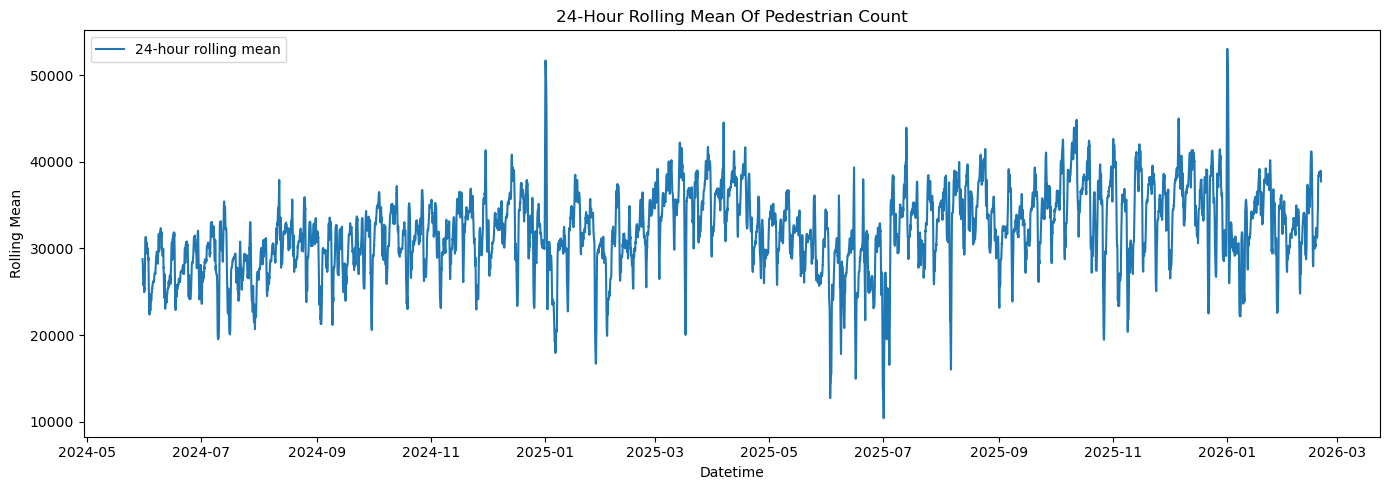

In [72]:
# Calculate the 24-hour rolling mean.
rolling_mean_24 = ts.rolling(24).mean()

# Plot the rolling mean only.
plt.figure(figsize=(14, 5))
plt.plot(
    rolling_mean_24,
    label="24-hour rolling mean"
)

plt.title("24-Hour Rolling Mean Of Pedestrian Count")
plt.xlabel("Datetime")
plt.ylabel("Rolling Mean")
plt.legend()
plt.tight_layout()
plt.show()

### 7.2 Seasonal Pattern (24-Hour Cycle)

Seasonal decomposition is necessary because hourly pedestrian demand is expected to have a strong daily cycle, so checking the seasonal component can help check how the typical hour of the day affects pedestrian activity. From the plot, it is clear that the seasonal effect is strongly negative at night and becomes strongly positive during the workday, especially the peak at 5 PM, when most people finish work and are looking to go home. The lowest tends to be around 3 AM, which is expected, since people tend to party late until 12 PM before heading home, and the other reason is that the city's pedestrian activities are very limited at that time. This plot further confirms that hour-of-day is a major driver of pedestrian demand, and there may be other variables influencing pedestrian demand.

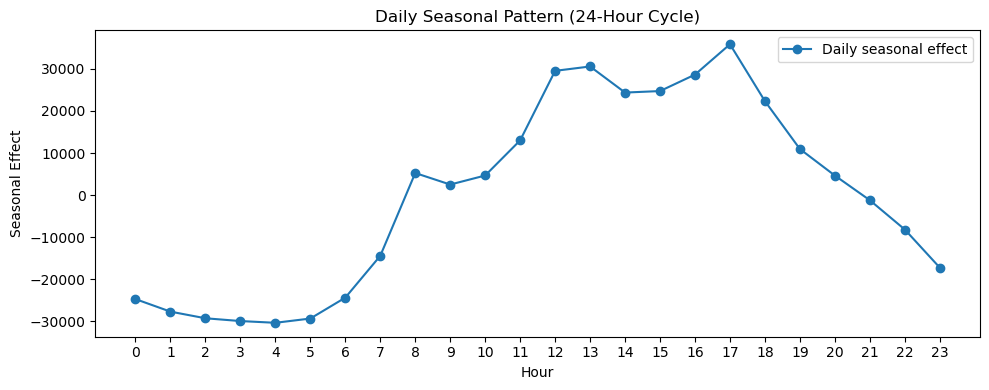

In [74]:
# Decompose the series using a 24-hour period.
decomp_24 = seasonal_decompose(
    ts,
    model="additive",
    period=24
)

# Store one seasonal cycle and align it to the actual hours.
seasonal_24 = pd.Series(
    decomp_24.seasonal[:24].values,
    index=ts.index[:24].hour
)

# Sort by actual hour.
seasonal_24 = seasonal_24.sort_index()

# Plot the corrected daily seasonal pattern.
plt.figure(figsize=(10, 4))
plt.plot(
    seasonal_24.index,
    seasonal_24.values,
    marker="o",
    label="Daily seasonal effect"
)

plt.title("Daily Seasonal Pattern (24-Hour Cycle)")
plt.xlabel("Hour")
plt.ylabel("Seasonal Effect")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

### 7.3 Autocorrelation Of Pedestrian Count

Checking for autocorrelation is important because it shows whether the current pedestrian demand depends on previous hours, and if strong dependence exists, then lag features will be very useful for forecasting. From the plot, there appears to be a very strong repeating pattern at a regular interval, especially around daily cycles. This repeated structure applies not only on the daily level, but also appears to be on the weekly level as well, meaning daily and weekly lag features will be useful for predictions.

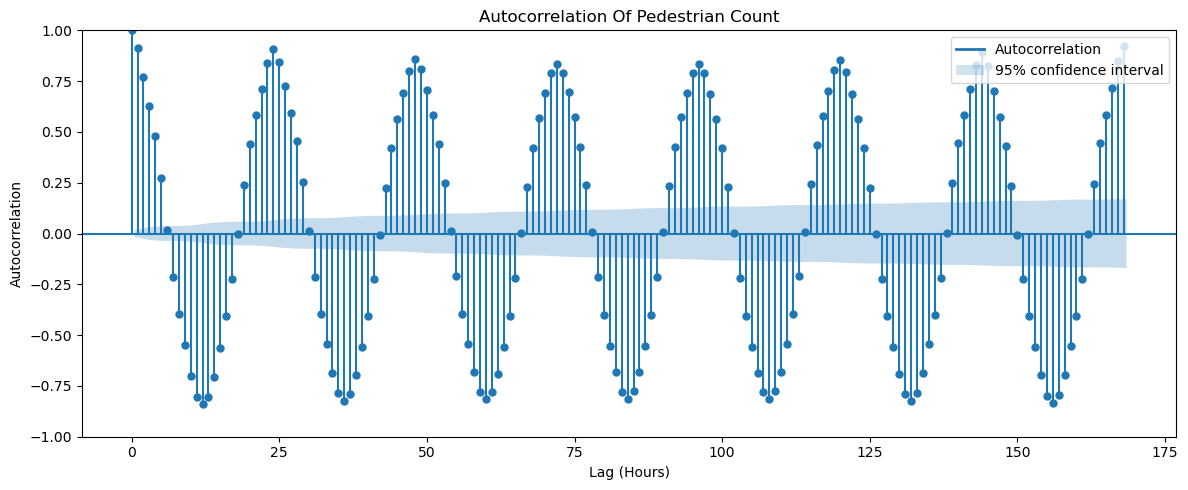

In [76]:
# Plot autocorrelation for one week of hourly lags.
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(ts, lags=168, ax=ax)

ax.set_title("Autocorrelation Of Pedestrian Count")
ax.set_xlabel("Lag (Hours)")
ax.set_ylabel("Autocorrelation")

# Add legend handles.
legend_handles = [
    Line2D([0], [0], color="C0", lw=2, label="Autocorrelation"),
    Patch(alpha=0.2, label="95% confidence interval")
]

ax.legend(handles=legend_handles, loc="upper right")
plt.tight_layout()
plt.show()

### 7.4 Augmented Dickey-Fuller Test

The Augmented Dickey-Fuller Test checks whether the time series is statistically stationary in the unit-root sense, and while not necessary for deep learning modelling, it does provide some more understanding of the patterns underlying the merged dataset.

The result was that the p-value is extremely small and the test statistic is far below the critical values, hence, the null hypothesis of a unit root is rejected. This means that the time series dataset is statistically stationary enough to exhibit a learnable structure rather than behaving like a random walk, which basically means that it's not necessarily a random coin toss in layman's terms.

In [78]:
# Run the Augmented Dickey-Fuller test.
adf_result = adfuller(ts)

# Print the results.
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -12.143911010852307
p-value: 1.6272075206909208e-22
Critical Values:
1%: -3.4307825096141857
5%: -2.861731150652329
10%: -2.5668717448588714


## 8. Feature Engineering

The feature engineering section is necessary because the current variables in the merged datasets may not necessarily be enough for a strong forecasting model, so doing feature engineering will create more useful variables that help capture other aspects of the datasets, like cyclical structures, recent history, and short-term trends.

### 8.1 Creating Time Features

Creating more calendar-based features is necessary because pedestrian activity depends on when that observation happened, as shown in previous plots. Hence, hours, day of week, month, and weekend status are all useful predictors. This step ensures the datetime_hour column is converted into its individual components.

In [81]:
# Create a copy for feature engineering.
features_df = model_df.copy()

# Extract calendar features.
features_df["hour"] = features_df["datetime_hour"].dt.hour
features_df["day_of_week"] = (
    features_df["datetime_hour"].dt.dayofweek
)
features_df["month"] = features_df["datetime_hour"].dt.month
features_df["is_weekend"] = (
    features_df["day_of_week"] >= 5
).astype(int)

# Check the result.
print(
    features_df[
        [
            "datetime_hour", "hour", "day_of_week", "month", 
            "is_weekend"
        ]
    ].head()
)

        datetime_hour  hour  day_of_week  month  is_weekend
0 2024-05-29 13:00:00    13            2      5           0
1 2024-05-29 14:00:00    14            2      5           0
2 2024-05-29 15:00:00    15            2      5           0
3 2024-05-29 16:00:00    16            2      5           0
4 2024-05-29 17:00:00    17            2      5           0


### 8.2 Creating Cyclical Time Features

Cyclical encoding is necessary since time variables are cyclical and not linear, like a clock. If we're talking just normal values like 0 and 23, these two values are quite far apart, but it's not, since it's time and there's only 1 hour difference. Using sine and cosine preserves that circular structure. This step ensures that the time variables are cyclical and prevents the models from learning misleading distances between values at the edge of a cycle.

In [83]:
# Hour and day of week are cyclical, not linear.
# Create cyclical hour features.
features_df["hour_sin"] = np.sin(
    2 * np.pi * features_df["hour"] / 24
)
features_df["hour_cos"] = np.cos(
    2 * np.pi * features_df["hour"] / 24
)

# Create cyclical day-of-week features.
features_df["dow_sin"] = np.sin(
    2 * np.pi * features_df["day_of_week"] / 7
)
features_df["dow_cos"] = np.cos(
    2 * np.pi * features_df["day_of_week"] / 7
)

# Convert cyclical month features.
features_df["month_sin"] = np.sin(
    2 * np.pi * features_df["month"] / 12
)
features_df["month_cos"] = np.cos(
    2 * np.pi * features_df["month"] / 12
)

# Check the result.
print(
    features_df[
        [
            "datetime_hour", "hour_sin", "hour_cos",
            "dow_sin", "dow_cos", "month_sin", 
            "month_cos"
        ]
    ].head()
)

        datetime_hour  hour_sin  hour_cos   dow_sin   dow_cos  month_sin  \
0 2024-05-29 13:00:00 -0.258819 -0.965926  0.974928 -0.222521        0.5   
1 2024-05-29 14:00:00 -0.500000 -0.866025  0.974928 -0.222521        0.5   
2 2024-05-29 15:00:00 -0.707107 -0.707107  0.974928 -0.222521        0.5   
3 2024-05-29 16:00:00 -0.866025 -0.500000  0.974928 -0.222521        0.5   
4 2024-05-29 17:00:00 -0.965926 -0.258819  0.974928 -0.222521        0.5   

   month_cos  
0  -0.866025  
1  -0.866025  
2  -0.866025  
3  -0.866025  
4  -0.866025  


### 8.3 Creating Cyclical Wind Direction Features

Wind direction is also circular, being 360 degrees, meaning 0 and 359 degrees are almost the same direction. So wind direction must also be converted to cyclical for a continuous form, and ensure consistency with treatments of cyclical variables like time.

In [85]:
# Convert wind direction into cyclical form.
features_df["wind_dir_sin"] = np.sin(
    2 * np.pi * features_df["averagewinddirection"] / 360
)
features_df["wind_dir_cos"] = np.cos(
    2 * np.pi * features_df["averagewinddirection"] / 360
)

# Check the result.
print(
    features_df[
        [
            "averagewinddirection",
            "wind_dir_sin",
            "wind_dir_cos"
        ]
    ].head()
)

   averagewinddirection  wind_dir_sin  wind_dir_cos
0            252.000000     -0.951057     -0.309017
1            240.148148     -0.867315     -0.497759
2            190.925926     -0.189540     -0.981873
3            238.040000     -0.848418     -0.529327
4            226.714286     -0.727944     -0.685637


### 8.4 Creating Lag Features

Lag features are important, as indicated by the autocorrelation plot, since pedestrian demand is highly dependent on recent history. Hence, the features lag_1, lag_24, and lag_168 capture the previous hour, previous day, and previous week at the same hour. This does create missing values since there wasn't recent information to populate the lag columns for specific rows, which will be dealt with. Like the very first row having a missing value for lag_1, because there wasn't a previous row to populate that value.

In [87]:
# Create lagged pedestrian count features.
features_df["lag_1"] = (
    features_df["pedestriancount"].shift(1)
)

features_df["lag_24"] = (
    features_df["pedestriancount"].shift(24)
)

features_df["lag_168"] = (
    features_df["pedestriancount"].shift(168)
)

# Check the result.
print(
    features_df[
        [
            "lag_1", "lag_24", "lag_168"
        ]
    ].head(25)
)

      lag_1   lag_24  lag_168
0       NaN      NaN      NaN
1   57628.0      NaN      NaN
2   46483.0      NaN      NaN
3   49846.0      NaN      NaN
4   58939.0      NaN      NaN
5   69055.0      NaN      NaN
6   48776.0      NaN      NaN
7   31556.0      NaN      NaN
8   26512.0      NaN      NaN
9   21317.0      NaN      NaN
10  16927.0      NaN      NaN
11   8038.0      NaN      NaN
12   3267.0      NaN      NaN
13   1913.0      NaN      NaN
14   1160.0      NaN      NaN
15    912.0      NaN      NaN
16   1099.0      NaN      NaN
17   2603.0      NaN      NaN
18   9251.0      NaN      NaN
19  21117.0      NaN      NaN
20  48415.0      NaN      NaN
21  39618.0      NaN      NaN
22  31462.0      NaN      NaN
23  34333.0      NaN      NaN
24  60229.0  57628.0      NaN


### 8.5 Creating Rolling Features

Rolling features summarise recent pedestrian counts rather than relying on a single observation for a datapoint, allowing the model to capture the short-term trend and help smooth the short-term noise. Hence, some new predictors were added, like rolling_mean_24, which summarises the previous 24 hours, while rolling_mean_168 summarises the previous week. And as expected, similar to lag features but not the same, the first rows are missing values since the rolling window cannot be calculated until enough history exists. 

In [89]:
# Create rolling mean features from past counts.
features_df["rolling_mean_24"] = (
    features_df["pedestriancount"]
    .shift(1)
    .rolling(24)
    .mean()
)

features_df["rolling_mean_168"] = (
    features_df["pedestriancount"]
    .shift(1)
    .rolling(168)
    .mean()
)

# Check the result.
print(
    features_df[
        [
            "rolling_mean_24", "rolling_mean_168"
        ]
    ].head(25)
)

    rolling_mean_24  rolling_mean_168
0               NaN               NaN
1               NaN               NaN
2               NaN               NaN
3               NaN               NaN
4               NaN               NaN
5               NaN               NaN
6               NaN               NaN
7               NaN               NaN
8               NaN               NaN
9               NaN               NaN
10              NaN               NaN
11              NaN               NaN
12              NaN               NaN
13              NaN               NaN
14              NaN               NaN
15              NaN               NaN
16              NaN               NaN
17              NaN               NaN
18              NaN               NaN
19              NaN               NaN
20              NaN               NaN
21              NaN               NaN
22              NaN               NaN
23              NaN               NaN
24          28769.0               NaN


### 8.6 Removing NA Rows

This step removes the rows with missing values created from the lag and rolling features at the beginning of the ordered merged dataset, since they cannot be used as they are incomplete predictor information. By removing these rows, the dataset lost a part of the early period as a trade-off in the pipeline, which is reasonable considering the dataset is being updated in real-time, so there will be more data points to use in the future, hence, negligible.

In [91]:
# Remove rows with NAs.
features_df = features_df.dropna().reset_index(drop=True)

# Check the result.
print(features_df.info())
print(features_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14998 entries, 0 to 14997
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime_hour         14998 non-null  datetime64[ns]
 1   pedestriancount       14998 non-null  int32         
 2   airtemperature        14998 non-null  float64       
 3   relativehumidity      14998 non-null  float64       
 4   atmosphericpressure   14998 non-null  float64       
 5   averagewindspeed      14998 non-null  float64       
 6   gustwindspeed         14998 non-null  float64       
 7   averagewinddirection  14998 non-null  float64       
 8   pm25                  14998 non-null  float64       
 9   pm10                  14998 non-null  float64       
 10  noise                 14998 non-null  float64       
 11  day_of_week           14998 non-null  int32         
 12  hour                  14998 non-null  int32         
 13  month           

### 8.7 Removing Unnecessary Features

Since the cyclical variables were created, the original raw cyclical variables have become redundant. So removing these variables helps reduce feature duplication and makes the modelling easier and cleaner. Hence, the averagewinddirection, hour, day_of_week, and month columns are dropped. Resulting in 24 columns, including the target pedestrian count, selected climate variables, is_weekend, cyclical encodings, lag features, and rolling means. The datetime_hour is temporarily kept, but will be removed later on as well.

In [93]:
# Drop raw columns that now have cyclical replacements.
features_df = features_df.drop(
    columns=[
        "averagewinddirection",
        "hour",
        "day_of_week",
        "month",
    ]
)

# Reorder the columns into a cleaner structure.
features_df = features_df[
    [
        "datetime_hour",
        "pedestriancount",
        "airtemperature",
        "relativehumidity",
        "atmosphericpressure",
        "averagewindspeed",
        "gustwindspeed",
        "pm25",
        "pm10",
        "noise",
        "is_weekend",
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
        "month_sin",
        "month_cos",
        "wind_dir_sin",
        "wind_dir_cos",
        "lag_1",
        "lag_24",
        "lag_168",
        "rolling_mean_24",
        "rolling_mean_168",
    ]
]

# Check the result.
print(features_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14998 entries, 0 to 14997
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   datetime_hour        14998 non-null  datetime64[ns]
 1   pedestriancount      14998 non-null  int32         
 2   airtemperature       14998 non-null  float64       
 3   relativehumidity     14998 non-null  float64       
 4   atmosphericpressure  14998 non-null  float64       
 5   averagewindspeed     14998 non-null  float64       
 6   gustwindspeed        14998 non-null  float64       
 7   pm25                 14998 non-null  float64       
 8   pm10                 14998 non-null  float64       
 9   noise                14998 non-null  float64       
 10  is_weekend           14998 non-null  int32         
 11  hour_sin             14998 non-null  float64       
 12  hour_cos             14998 non-null  float64       
 13  dow_sin              14998 non-

## 9. Preparing Train/Val/Test Splits

Preparing the splits is necessary for training a forecasting model, so that the future periods are evaluated, and not on randomly selected time periods. Hence, splitting the dataset based on time is important so that the model being trained on the past can predict the future, like in real-world scenarios.

### 9.1 Splitting The Data By Time

Chronological splitting in time-series forecasting is to prevent leaking future information into the training process. For example is if random splitting were to be used, then a model can be trained on data points in 2026, but is tested on a time period in 2025. Hence, the validation and test set must be later, and the training set must be the past, as shown here.

The split for training, validation and testing is 80:10:10 to ensure that there are enough data points used for training, with enough data points to perform validation and testing. Deep learning tends to require a large number of data points, so using this split ratio prevents underfitting.

In [96]:
# Set the split sizes (80:10:10).
train_size = int(len(features_df) * 0.8)
val_size = int(len(features_df) * 0.1)

# Split the data in chronological order.
train_df = features_df.iloc[:train_size].copy()
val_df = features_df.iloc[
    train_size:train_size + val_size
].copy()
test_df = features_df.iloc[
    train_size + val_size:
].copy()

# Check the shapes.
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(11998, 24)
(1499, 24)
(1501, 24)


In [97]:
# Checking The Split Ranges.
print("Train range:")
print(train_df["datetime_hour"].min())
print(train_df["datetime_hour"].max())

print("\nValidation range:")
print(val_df["datetime_hour"].min())
print(val_df["datetime_hour"].max())

print("\nTest range:")
print(test_df["datetime_hour"].min())
print(test_df["datetime_hour"].max())

Train range:
2024-06-05 13:00:00
2025-10-18 10:00:00

Validation range:
2025-10-18 11:00:00
2025-12-19 21:00:00

Test range:
2025-12-19 22:00:00
2026-02-20 10:00:00


### 9.2 Separating Features And Target

This step is necessary to separate the predictor inputs X and the output target y. The target is set to pedestriancount, which is the variable the model is trying to predict. The datetime column is excluded from the features since the chronological splitting is completed, so this leaves 22 predictor columns for each split, as shown in the shapes output.

In [99]:
# Store the target column name.
target_col = "pedestriancount"

# Store the feature column names.
feature_cols = [
    col for col in features_df.columns
    if col not in ["datetime_hour", target_col]
]

# Create X and y for each split.
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

# Check the shapes.
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(11998, 22) (11998,)
(1499, 22) (1499,)
(1501, 22) (1501,)


### 9.3 Scaling The Features

Scaling is important to ensure that the predictors are standardised so that the variables are unitless, allowing the variables to be able to directly compared. Standardisation basically sets the predictors to have a mean of 0 and a standard deviation of 1. This allows faster convergence when all the input features are on the same scale, preventing feature dominance due to differences in magnitudes, and is generally more stable.

In [101]:
# Create the scaler.
scaler = StandardScaler()

# Fit on training features only.
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test features.
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Check the shapes.
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)
print(X_train_scaled[:5])

(11998, 22)
(1499, 22)
(1501, 22)
[[-0.25917082  0.29404521  0.44458648 -0.20251436 -0.45919765 -0.10819435
   1.05388729  0.60401279 -0.63129335 -0.36596644 -1.36636342  1.37933732
  -0.3088925   0.25826753 -1.27852587 -1.10176994  0.1948997   1.10486749
   0.92753388  1.08744999 -1.18579056 -1.54627077]
 [-0.26879797  0.23225894  0.45019736 -0.17397887 -0.24207515 -0.16932953
   0.73538055  0.53784354 -0.63129335 -0.7070213  -1.2250719   1.37933732
  -0.3088925   0.25826753 -1.27852587  0.21591715 -0.80547699  0.79825043
   0.40082715  0.62381546 -1.21402636 -1.55950048]
 [-0.20362957 -0.17301712  0.46141912 -0.05270306  0.06732442 -0.18266811
   0.6747126   0.15317963 -0.63129335 -0.99989174 -1.00030954  1.37933732
  -0.3088925   0.25826753 -1.27852587  0.22921459 -0.80371765  0.56417802
   0.53080505  0.76371702 -1.17761198 -1.56190355]
 [-0.20807287 -0.24920273  0.46325124 -0.28812081 -0.29635577 -0.24046865
   0.4168738   0.22552467 -0.63129335 -1.22461914 -0.70739354  1.37933732